In [1]:
# Segmenting Shopping Mall Customers
# Unsupervised Learning Homework


import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [2]:
# Problem 1: Load and preparee the data
cust = pd.read_csv("mallcustomers.csv")


#review the data
print(cust.head(), "\n")

#review the datatypes
print(cust.dtypes, "\n")

   CustomerID  Gender  Age      Income  SpendingScore
0           1    Male   19  15,000 USD             39
1           2    Male   21  15,000 USD             81
2           3  Female   20  16,000 USD              6
3           4  Female   23  16,000 USD             77
4           5  Female   31  17,000 USD             40 

CustomerID        int64
Gender           object
Age               int64
Income           object
SpendingScore     int64
dtype: object 



In [3]:
# Clean Income: remove commas and USD, then convert to numeric
cust["Income"] = (
    cust["Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.strip()
)

cust["Income"] = pd.to_numeric(cust["Income"], errors="coerce")


#Review the data after cleansing
print(cust.dtypes, "\n")

CustomerID        int64
Gender           object
Age               int64
Income            int64
SpendingScore     int64
dtype: object 



In [4]:
# Problem 2: drop CustomerID
cust = cust.drop(columns=["CustomerID"])

#Review and verify customerid has been dropped
print(cust.columns, "\n")

Index(['Gender', 'Age', 'Income', 'SpendingScore'], dtype='object') 



In [5]:
# Problem 3: Summary stats + z-score normalization
print("Summary Statistics for Income & SpendingScore:")
print(cust[["Income", "SpendingScore"]].describe(), "\n")

# Keep a copy before scaling later on
cust_original = cust.copy()


Summary Statistics for Income & SpendingScore:
              Income  SpendingScore
count     200.000000     200.000000
mean    60560.000000      50.200000
std     26264.721165      25.823522
min     15000.000000       1.000000
25%     41500.000000      34.750000
50%     61500.000000      50.000000
75%     78000.000000      73.000000
max    137000.000000      99.000000 



In [6]:
# z-score normalization
cust["Income_z"] = (cust["Income"] - cust["Income"].mean()) / cust["Income"].std()
cust["SpendingScore_z"] = (cust["SpendingScore"] - cust["SpendingScore"].mean()) / cust["SpendingScore"].std()

#review the z-score normalizations
print(cust[["Income_z", "SpendingScore_z"]].head(), "\n")

X = cust[["Income_z", "SpendingScore_z"]]


   Income_z  SpendingScore_z
0 -1.734646        -0.433713
1 -1.734646         1.192711
2 -1.696572        -1.711618
3 -1.696572         1.037814
4 -1.658498        -0.394989 



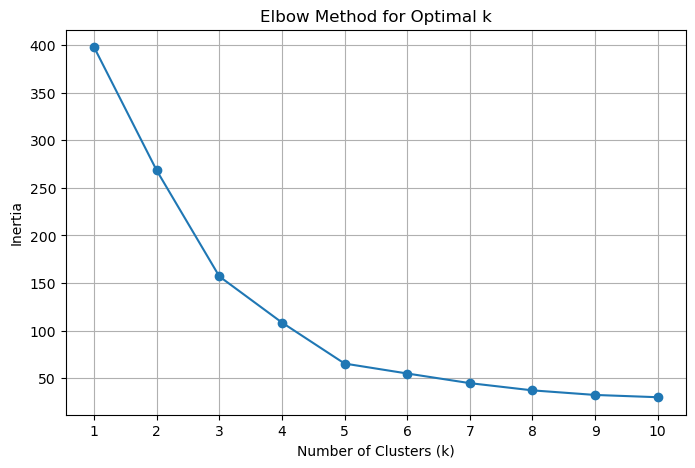

In [7]:
# Problem 4: Elbow Method

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)


#Plot it out
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()



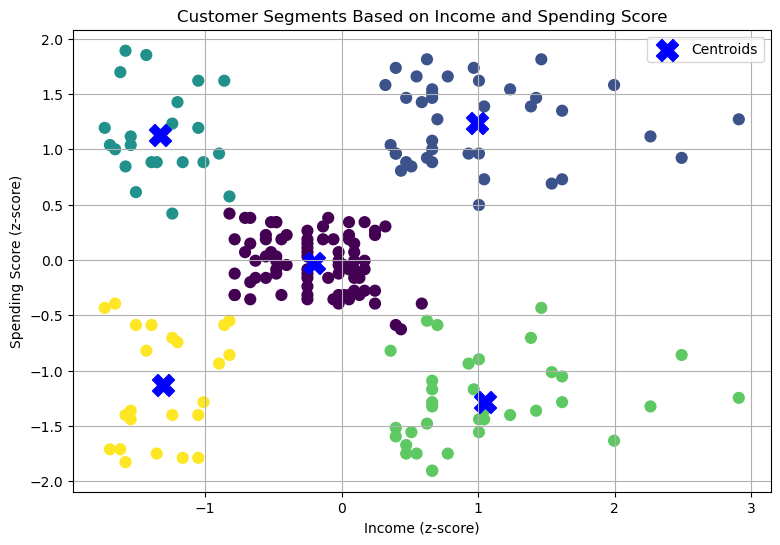

In [8]:
# Based on the elbow plot, choose optimal_k = 5
optimal_k = 5

# Final k-means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cust["Cluster"] = kmeans_final.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(9, 6))
plt.scatter(
    cust["Income_z"],
    cust["SpendingScore_z"],
    c=cust["Cluster"],
    s=60
)

# Plot the centroids
centroids = kmeans_final.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    color="Blue",
    label="Centroids"
)

plt.title("Customer Segments Based on Income and Spending Score")
plt.xlabel("Income (z-score)")
plt.ylabel("Spending Score (z-score)")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Problem 5: Name clusters + demographics
# Create 'dummy' variables for Gender
cust["Male"] = (cust_original["Gender"] == "Male").astype(int)
cust["Female"] = (cust_original["Gender"] == "Female").astype(int)

# Add original Age, Income, SpendingScore back for summary
cust["Age"] = cust_original["Age"]
cust["Income"] = cust_original["Income"]
cust["SpendingScore"] = cust_original["SpendingScore"]

In [10]:
#Output Summary
cluster_summary = cust.groupby("Cluster").agg(
    Mean_Income=("Income", "mean"),
    Mean_SpendingScore=("SpendingScore", "mean"),
    Mean_Age=("Age", "mean"),
    Male_Proportion=("Male", "mean"),
    Female_Proportion=("Female", "mean"),
    Count=("Cluster", "size")
).round(2)

#review the summary
print(cluster_summary, "\n")




         Mean_Income  Mean_SpendingScore  Mean_Age  Male_Proportion  \
Cluster                                                               
0           55296.30               49.52     42.72             0.41   
1           86538.46               82.13     32.69             0.46   
2           25727.27               79.36     25.27             0.41   
3           88200.00               17.11     41.11             0.54   
4           26304.35               20.91     45.22             0.39   

         Female_Proportion  Count  
Cluster                            
0                     0.59     81  
1                     0.54     39  
2                     0.59     22  
3                     0.46     35  
4                     0.61     23   



In [11]:
# Give names to clusters based on cluster averages
overall_income_mean = cust["Income"].mean()
overall_spending_mean = cust["SpendingScore"].mean()

def name_cluster(row):
    if row["Mean_Income"] > overall_income_mean and row["Mean_SpendingScore"] > overall_spending_mean:
        return "High Income / High Spending"
    elif row["Mean_Income"] > overall_income_mean and row["Mean_SpendingScore"] <= overall_spending_mean:
        return "High Income / Low Spending"
    elif row["Mean_Income"] <= overall_income_mean and row["Mean_SpendingScore"] > overall_spending_mean:
        return "Low Income / High Spending"
    else:
        return "Low Income / Low Spending"

cluster_summary["Cluster_Name"] = cluster_summary.apply(name_cluster, axis=1)

#Review the cluster summary
print(cluster_summary, "\n")



         Mean_Income  Mean_SpendingScore  Mean_Age  Male_Proportion  \
Cluster                                                               
0           55296.30               49.52     42.72             0.41   
1           86538.46               82.13     32.69             0.46   
2           25727.27               79.36     25.27             0.41   
3           88200.00               17.11     41.11             0.54   
4           26304.35               20.91     45.22             0.39   

         Female_Proportion  Count                 Cluster_Name  
Cluster                                                         
0                     0.59     81    Low Income / Low Spending  
1                     0.54     39  High Income / High Spending  
2                     0.59     22   Low Income / High Spending  
3                     0.46     35   High Income / Low Spending  
4                     0.61     23    Low Income / Low Spending   



In [12]:
# print cluster descriptions
for cluster_id, row in cluster_summary.iterrows():
    print(f"Cluster {cluster_id}: {row['Cluster_Name']}")
    print(f"  Count: {row['Count']}")
    print(f"  Mean Income: {row['Mean_Income']}")
    print(f"  Mean Spending Score: {row['Mean_SpendingScore']}")
    print(f"  Mean Age: {row['Mean_Age']}")
    print(f"  Male Proportion: {row['Male_Proportion']:.2%}")
    print(f"  Female Proportion: {row['Female_Proportion']:.2%}")
    print()

Cluster 0: Low Income / Low Spending
  Count: 81
  Mean Income: 55296.3
  Mean Spending Score: 49.52
  Mean Age: 42.72
  Male Proportion: 41.00%
  Female Proportion: 59.00%

Cluster 1: High Income / High Spending
  Count: 39
  Mean Income: 86538.46
  Mean Spending Score: 82.13
  Mean Age: 32.69
  Male Proportion: 46.00%
  Female Proportion: 54.00%

Cluster 2: Low Income / High Spending
  Count: 22
  Mean Income: 25727.27
  Mean Spending Score: 79.36
  Mean Age: 25.27
  Male Proportion: 41.00%
  Female Proportion: 59.00%

Cluster 3: High Income / Low Spending
  Count: 35
  Mean Income: 88200.0
  Mean Spending Score: 17.11
  Mean Age: 41.11
  Male Proportion: 54.00%
  Female Proportion: 46.00%

Cluster 4: Low Income / Low Spending
  Count: 23
  Mean Income: 26304.35
  Mean Spending Score: 20.91
  Mean Age: 45.22
  Male Proportion: 39.00%
  Female Proportion: 61.00%



In [ ]:
# Segmenting Shopping Mall Customers
# Unsupervised Learning Homework


import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Problem 1: Load and preparee the data
cust = pd.read_csv("mallcustomers.csv")


#review the data
print(cust.head(), "\n")

#review the datatypes
print(cust.dtypes, "\n")
# Clean Income: remove commas and USD, then convert to numeric
cust["Income"] = (
    cust["Income"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("USD", "", regex=False)
    .str.strip()
)

cust["Income"] = pd.to_numeric(cust["Income"], errors="coerce")


#Review the data after cleansing
print(cust.dtypes, "\n")
# Problem 2: drop CustomerID
cust = cust.drop(columns=["CustomerID"])

#Review and verify customerid has been dropped
print(cust.columns, "\n")
# Problem 3: Summary stats + z-score normalization
print("Summary Statistics for Income & SpendingScore:")
print(cust[["Income", "SpendingScore"]].describe(), "\n")

# Keep a copy before scaling later on
cust_original = cust.copy()
# z-score normalization
cust["Income_z"] = (cust["Income"] - cust["Income"].mean()) / cust["Income"].std()
cust["SpendingScore_z"] = (cust["SpendingScore"] - cust["SpendingScore"].mean()) / cust["SpendingScore"].std()

#review the z-score normalizations
print(cust[["Income_z", "SpendingScore_z"]].head(), "\n")

X = cust[["Income_z", "SpendingScore_z"]]
# Problem 4: Elbow Method

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)


#Plot it out
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# Based on the elbow plot, choose optimal_k = 5
optimal_k = 5

# Final k-means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cust["Cluster"] = kmeans_final.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(9, 6))
plt.scatter(
    cust["Income_z"],
    cust["SpendingScore_z"],
    c=cust["Cluster"],
    s=60
)

# Plot the centroids
centroids = kmeans_final.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    color="Blue",
    label="Centroids"
)

plt.title("Customer Segments Based on Income and Spending Score")
plt.xlabel("Income (z-score)")
plt.ylabel("Spending Score (z-score)")
plt.legend()
plt.grid(True)
plt.show()

# Problem 5: Name clusters + demographics
# Create 'dummy' variables for Gender
cust["Male"] = (cust_original["Gender"] == "Male").astype(int)
cust["Female"] = (cust_original["Gender"] == "Female").astype(int)

# Add original Age, Income, SpendingScore back for summary
cust["Age"] = cust_original["Age"]
cust["Income"] = cust_original["Income"]
cust["SpendingScore"] = cust_original["SpendingScore"]

#Output Summary
cluster_summary = cust.groupby("Cluster").agg(
    Mean_Income=("Income", "mean"),
    Mean_SpendingScore=("SpendingScore", "mean"),
    Mean_Age=("Age", "mean"),
    Male_Proportion=("Male", "mean"),
    Female_Proportion=("Female", "mean"),
    Count=("Cluster", "size")
).round(2)

#review the summary
print(cluster_summary, "\n")

# Give names to clusters based on cluster averages
overall_income_mean = cust["Income"].mean()
overall_spending_mean = cust["SpendingScore"].mean()

def name_cluster(row):
    if row["Mean_Income"] > overall_income_mean and row["Mean_SpendingScore"] > overall_spending_mean:
        return "High Income / High Spending"
    elif row["Mean_Income"] > overall_income_mean and row["Mean_SpendingScore"] <= overall_spending_mean:
        return "High Income / Low Spending"
    elif row["Mean_Income"] <= overall_income_mean and row["Mean_SpendingScore"] > overall_spending_mean:
        return "Low Income / High Spending"
    else:
        return "Low Income / Low Spending"

cluster_summary["Cluster_Name"] = cluster_summary.apply(name_cluster, axis=1)

#Review the cluster summary
print(cluster_summary, "\n")

# print cluster descriptions
for cluster_id, row in cluster_summary.iterrows():
    print(f"Cluster {cluster_id}: {row['Cluster_Name']}")
    print(f"  Count: {row['Count']}")
    print(f"  Mean Income: {row['Mean_Income']}")
    print(f"  Mean Spending Score: {row['Mean_SpendingScore']}")
    print(f"  Mean Age: {row['Mean_Age']}")
    print(f"  Male Proportion: {row['Male_Proportion']:.2%}")
    print(f"  Female Proportion: {row['Female_Proportion']:.2%}")
    print()